In [ ]:
import pandas as pd
import numpy as np


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

In [ ]:
df=pd.read_csv("train.csv",usecols=['Age','Fare','Survived'])

In [ ]:
df.dropna(inplace=True)

In [ ]:
df.shape

(714, 3)

In [ ]:
df.head(6)

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500
6,0,54.0,51.8625


In [ ]:
x=df.iloc[:,1:]
y= df.iloc[:,0]

In [ ]:
x_train ,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.head()

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542
253,30.0,16.1000
719,33.0,7.7750
666,25.0,13.0000


In [ ]:
clf = DecisionTreeClassifier()

In [ ]:
clf.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred=clf.predict(x_test)

In [ ]:
accuracy_score(y_test, y_pred) * 100

62.93706293706294

In [ ]:
# now cross- validating the accuracy score
np.mean (cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy'))

np.float64(0.6316901408450704)

## Applying binning

Types of Discretization(binning):
* Unifrom (equal binning)
* Quantiles (equal Frequency)
* k-means binning



In [ ]:
kbin_age =KBinsDiscretizer(n_bins=10, encode="ordinal",strategy="uniform")
kbin_fare =KBinsDiscretizer(n_bins=10, encode="ordinal",strategy="uniform")

In [ ]:
trf= ColumnTransformer ([
    ('first',kbin_age,[0]),
    ("second",kbin_fare,[1])
])

In [ ]:
x_train_trf = trf.fit_transform(x_train)
x_test_trf = trf.transform(x_test)

In [ ]:
trf.named_transformers_['first'].n_bins_

array([10])

In [ ]:
trf.named_transformers_['second'].bin_edges_  #the range of bins created

array([array([  0.     ,  51.23292, 102.46584, 153.69876, 204.93168, 256.1646 ,
              307.39752, 358.63044, 409.86336, 461.09628, 512.3292 ])          ],
      dtype=object)

In [ ]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42 ,  8.378, 16.336, 24.294, 32.252, 40.21 , 48.168, 56.126,
              64.084, 72.042, 80.   ])                                       ],
      dtype=object)

In [ ]:
output =pd.DataFrame({
    'age':x_train['Age'],
    'age_trf':x_train_trf[:,0],
    'fare':x_train['Fare'],
    'fare_trf':x_train_trf[:,1]
})


In [ ]:
output.sample(5)

,age,age_trf,fare,fare_trf
174,56.0,6.0,30.6958,0.0
408,21.0,2.0,7.7750,0.0
27,19.0,2.0,263.0000,5.0
543,32.0,3.0,26.0000,0.0
791,16.0,1.0,26.0000,0.0


In [ ]:
clf = DecisionTreeClassifier()
clf.fit(x_train_trf,y_train)
y_pred2=clf.predict(x_test_trf)

accuracy_score(y_test,y_pred2)

0.6783216783216783

In [ ]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)

    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])

    x_trf = trf.fit_transform(x)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),x,y,cv=10,scoring='accuracy')))

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,0],color='red')
    plt.title("After")

    plt.show()

    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(x['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(x_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()


0.6358568075117371


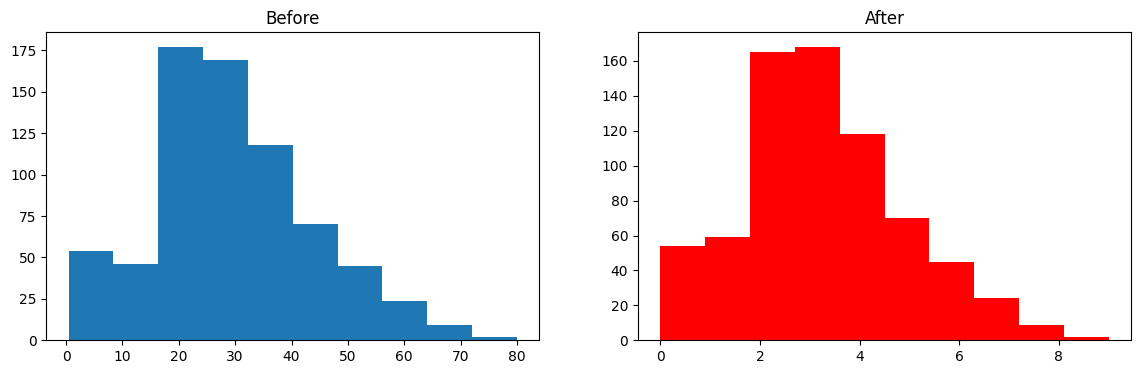

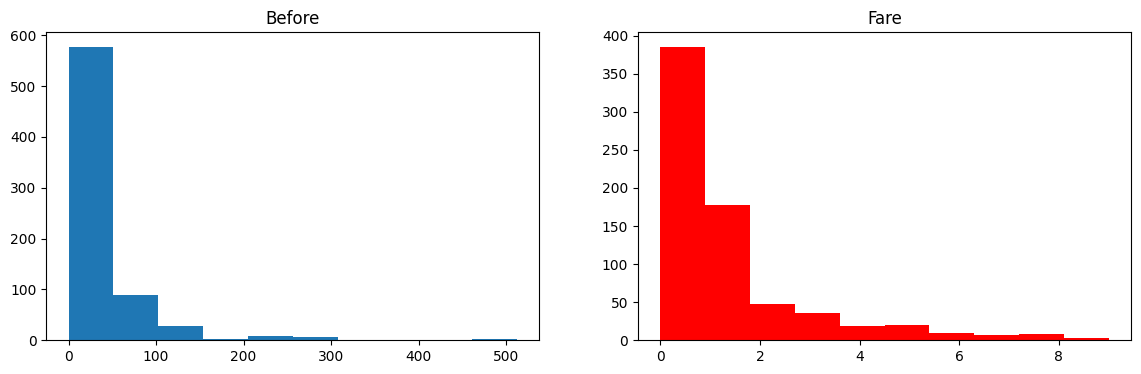

In [ ]:
discretize(10,'kmeans')

## Custom / Domain Based Binning